In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from RQ1_synth_data.train_real import run

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-139


2025-08-05 14:00:31 INFO     Logs will be written to output/test/20250805_140031/log_training.txt
2025-08-05 14:00:31 INFO     Found 675 files in /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles
2025-08-05 14:00:50 INFO     Number of valid images: 518
2025-08-05 14:00:50 INFO     Number of files limited to: 518
2025-08-05 14:01:15 INFO     ✅ Community A: 104 images
2025-08-05 14:01:15 INFO     ✅ Community B: 348 images
2025-08-05 14:01:15 INFO     ⚠️ Ambiguous: 66 images discarded due to overlap
2025-08-05 14:01:15 INFO     Will start training from scratch
[neptune] [warning] NeptuneUnsupportedType: You're attempting to log a type that is not directly supported by Neptune (<class 'NoneType'>).
        Convert the value to a supported type, such as a string or float, or use stringify_unsupported(obj)
        for dictionaries or collections that contain unsupported values.
        For more, see https://docs-legacy.neptune.ai/

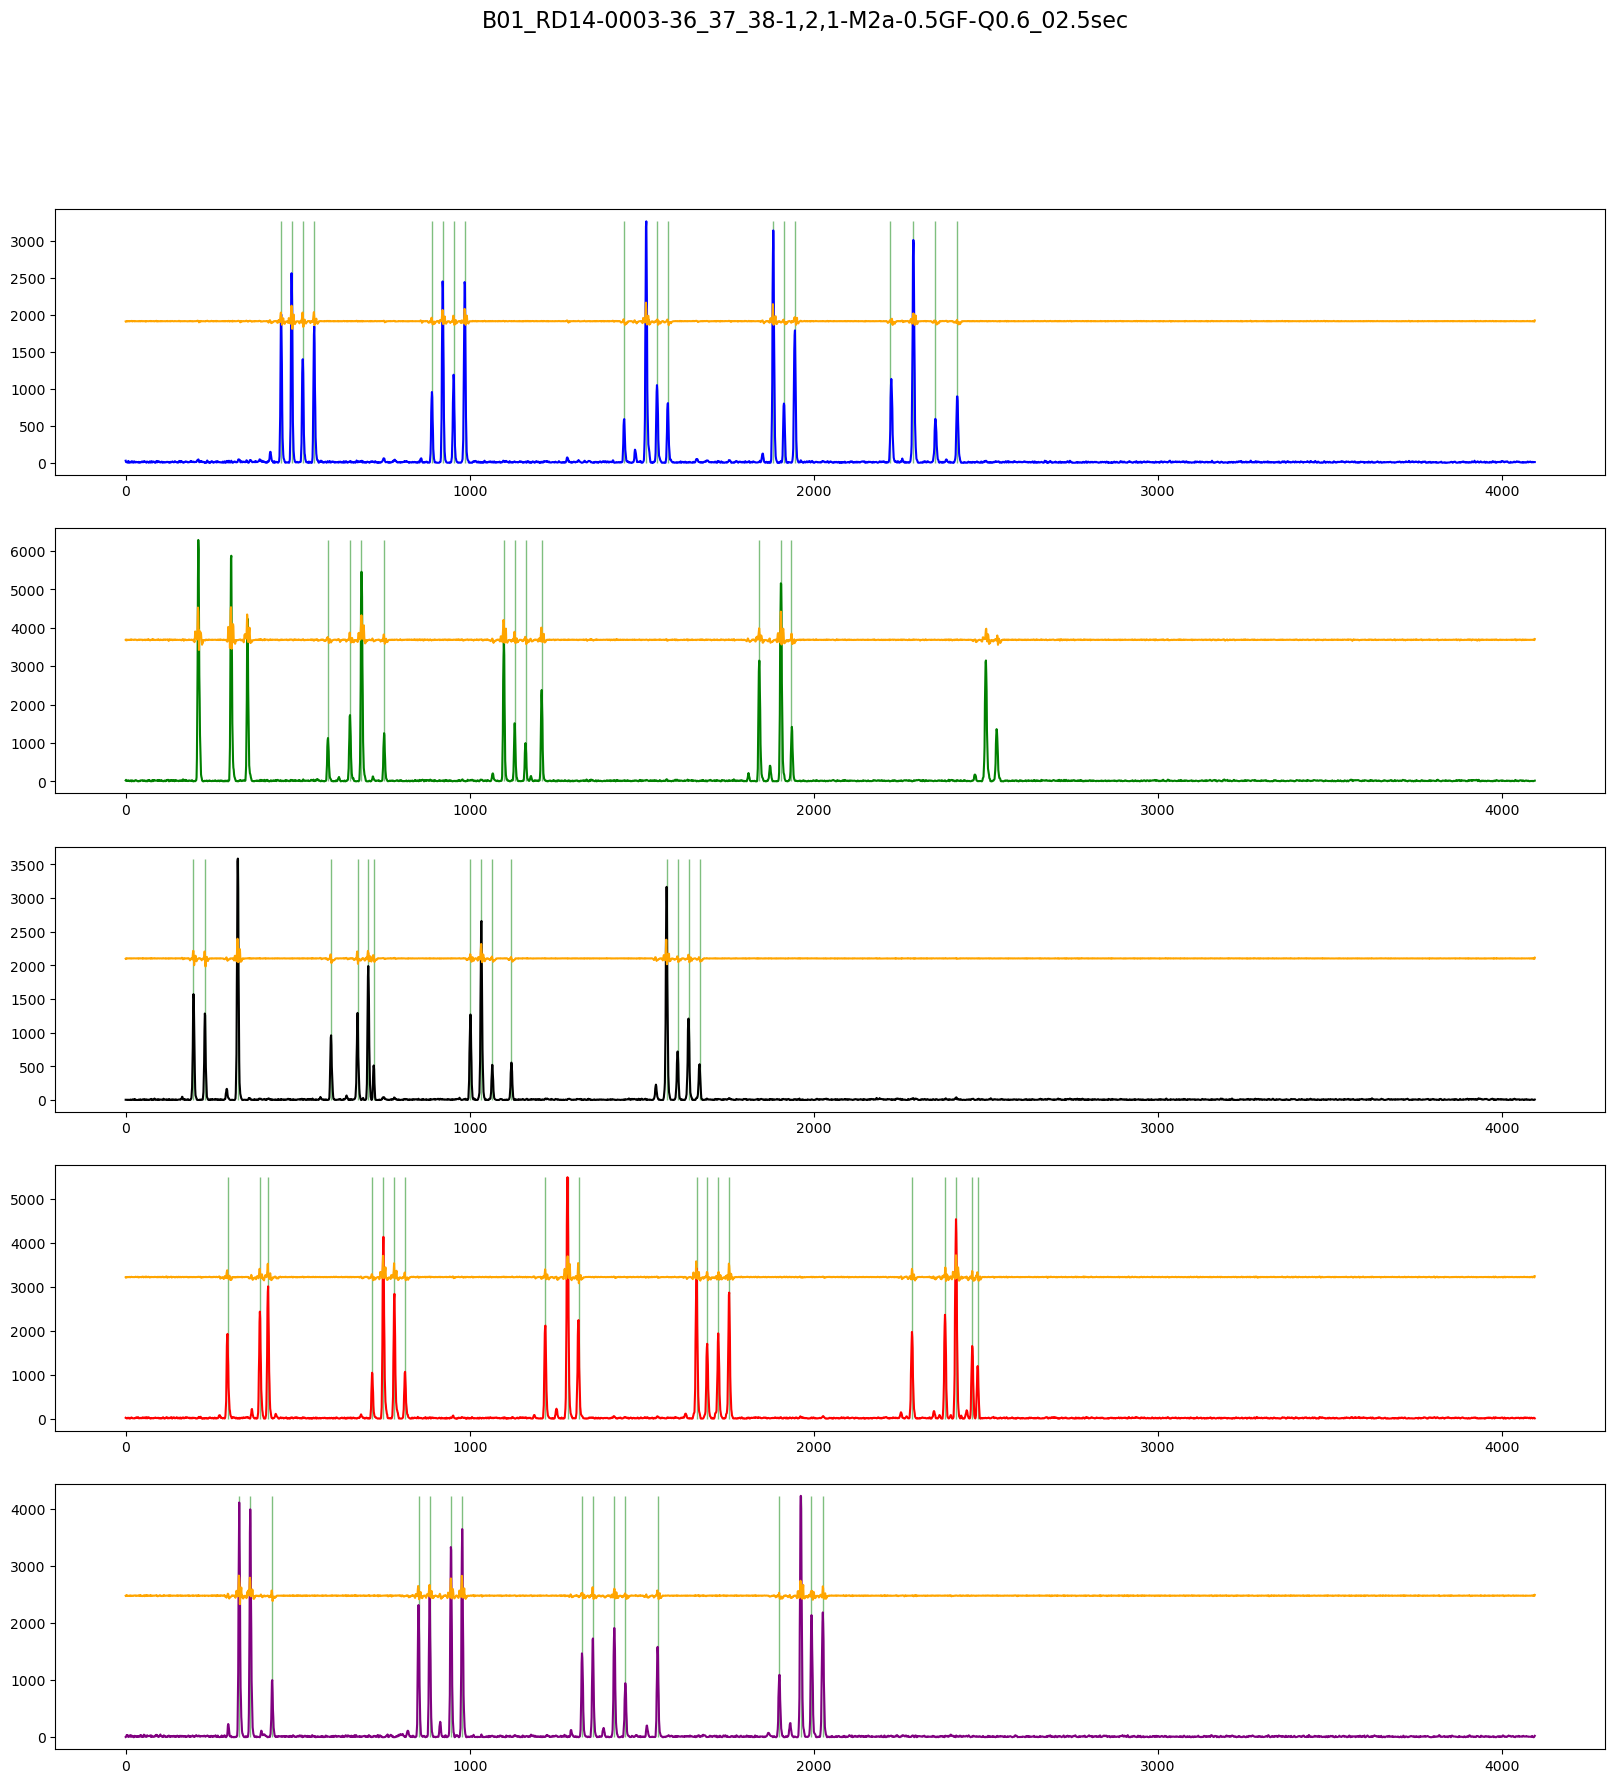

2025-08-05 14:01:38 INFO     Saved best model with loss 0.992659 at epoch 1.
2025-08-05 14:01:38 INFO     Epoch 1/200: scheduler decreased learning rate to 1.0701565640002832e-05
Epoch 2/200: 100%|██████████| 3/3 [00:04<00:00,  1.52s/it, training_loss=0.993]
2025-08-05 14:01:42 INFO     Epoch 2/200 - Training binaryaccuracy: 0.003340
2025-08-05 14:01:42 INFO     Epoch 2/200 - Training loss: 0.992663
Epoch 2/200: 6it [00:02,  2.10it/s, validation_loss=0.992]                       
2025-08-05 14:01:49 INFO     Epoch 2/200 - Validation metric (BinaryAccuracy()): 0.004095 | Validation loss: 0.992407
2025-08-05 14:01:49 INFO     Epoch 2/200 - Validation binaryaccuracy: 0.003692
2025-08-05 14:01:52 INFO     Calling alleles from predicted segmentation...
2025-08-05 14:01:55 INFO     Saved best model with loss 0.992407 at epoch 2.
2025-08-05 14:01:55 INFO     Epoch 2/200: scheduler decreased learning rate to 1.2804273895982224e-05
Epoch 3/200: 100%|██████████| 3/3 [00:03<00:00,  1.26s/it, trai

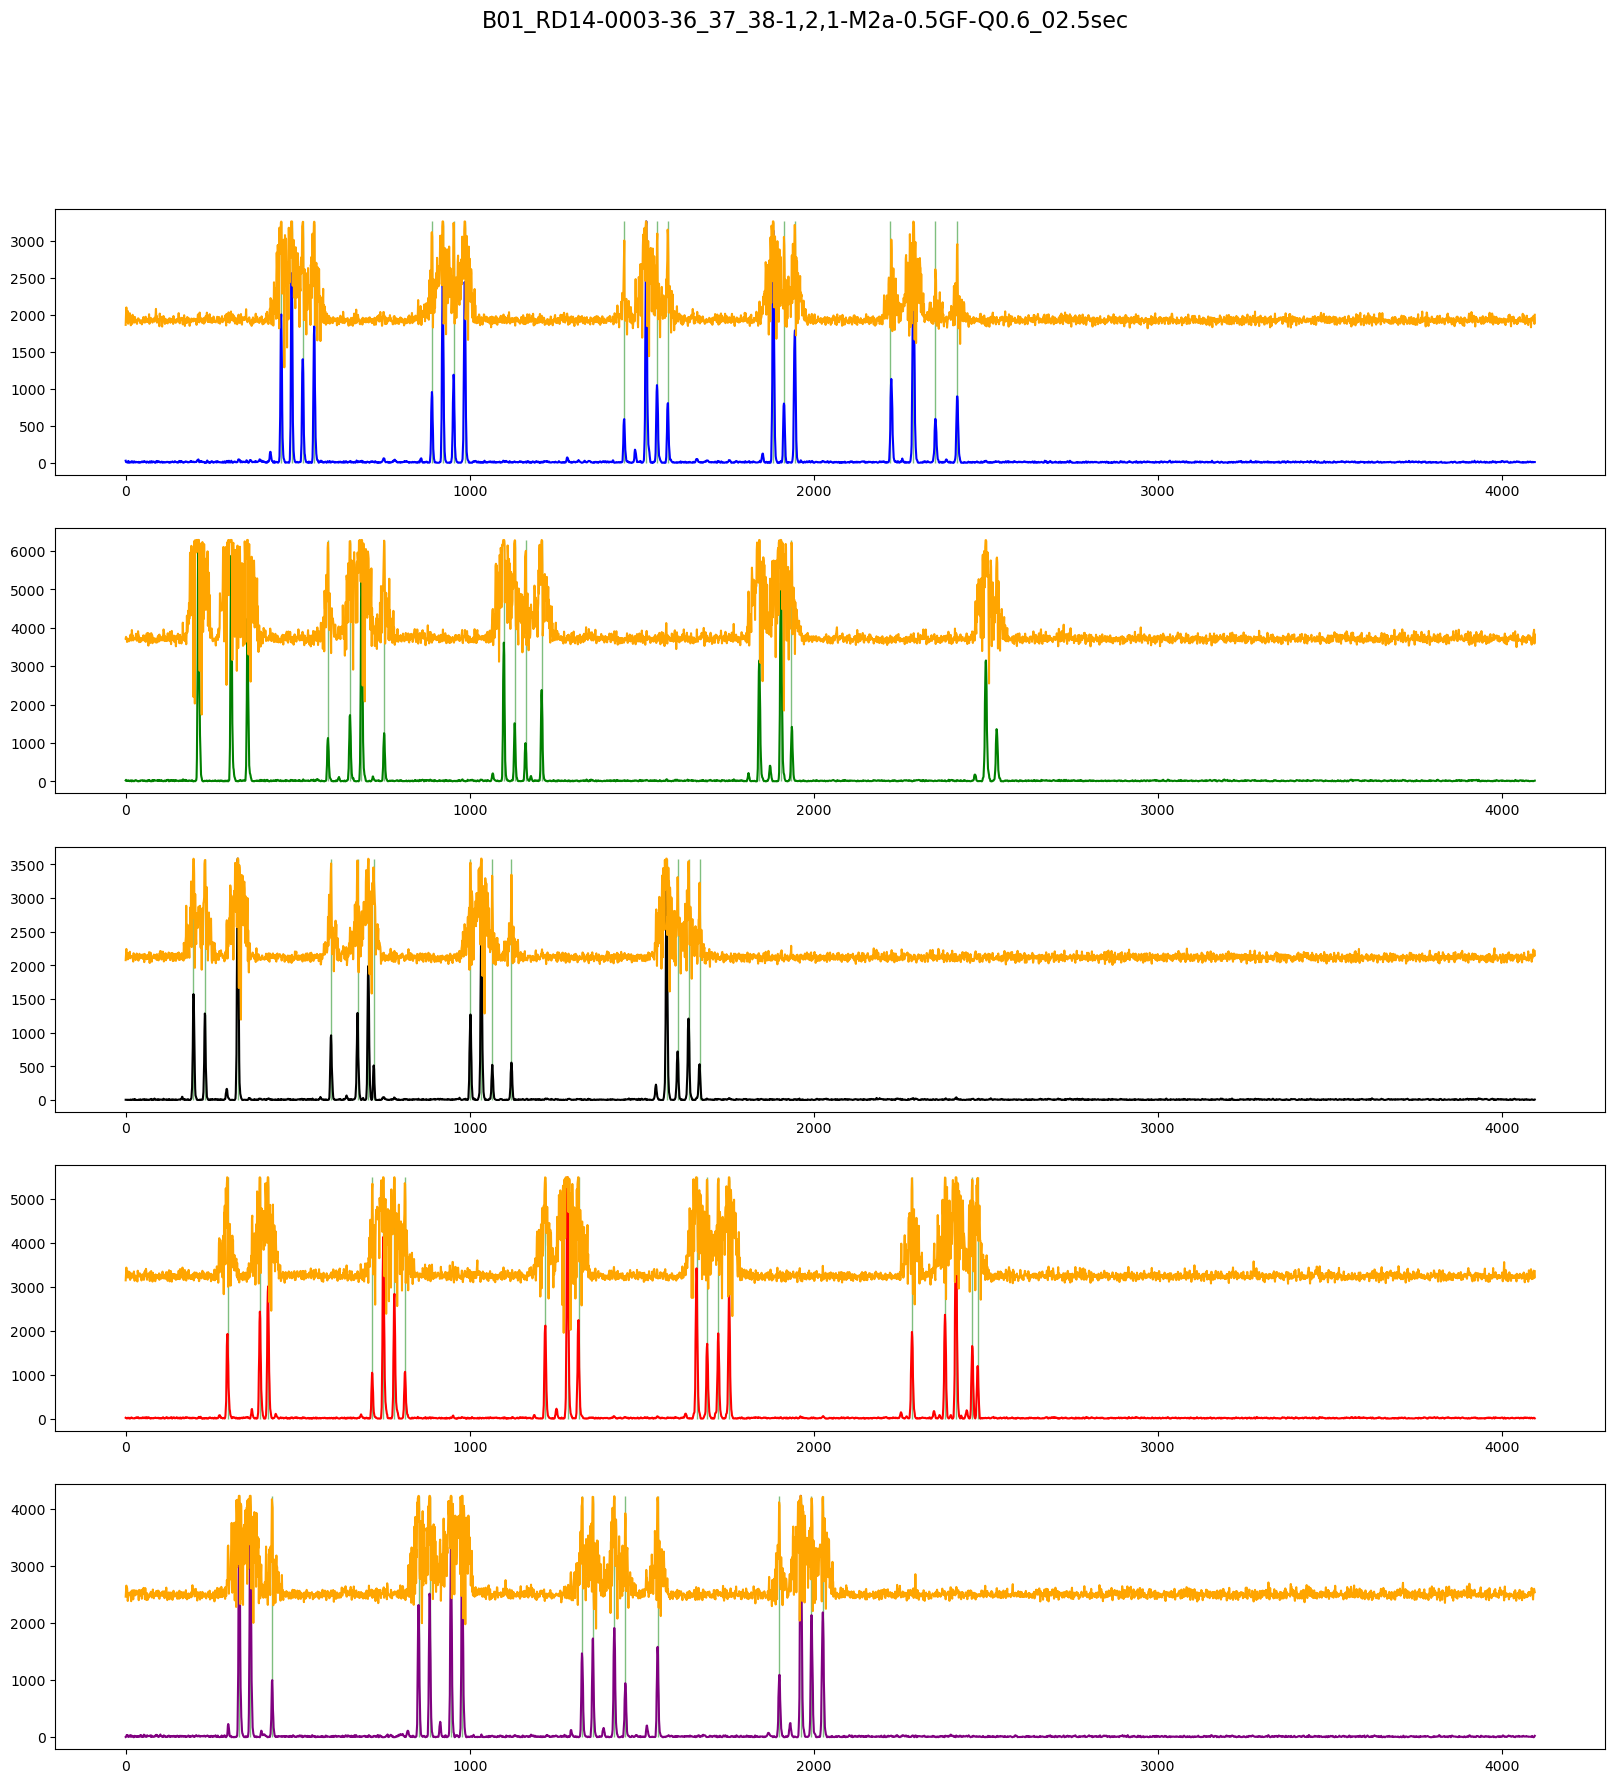

2025-08-05 14:04:00 INFO     Saved best model with loss 0.990348 at epoch 11.
2025-08-05 14:04:00 INFO     Epoch 11/200: scheduler decreased learning rate to 9.250961005415515e-05
Epoch 12/200: 100%|██████████| 3/3 [00:03<00:00,  1.09s/it, training_loss=0.992]
2025-08-05 14:04:04 INFO     Epoch 12/200 - Training binaryaccuracy: 0.003450
2025-08-05 14:04:04 INFO     Epoch 12/200 - Training loss: 0.991975
Epoch 12/200: 6it [00:01,  3.18it/s, validation_loss=0.99]                        
2025-08-05 14:04:09 INFO     Epoch 12/200 - Validation metric (BinaryAccuracy()): 0.004169 | Validation loss: 0.990222
2025-08-05 14:04:09 INFO     Epoch 12/200 - Validation binaryaccuracy: 0.004136
2025-08-05 14:04:11 INFO     Calling alleles from predicted segmentation...
2025-08-05 14:04:14 INFO     Saved best model with loss 0.990222 at epoch 12.
2025-08-05 14:04:14 INFO     Epoch 12/200: scheduler decreased learning rate to 0.00010765773922417302
Epoch 13/200: 100%|██████████| 3/3 [00:03<00:00,  1.13

In [ ]:
run(
    data_config="provedit_data.yaml",
    model_config="unet_amar.yaml",
    training_config="training_amar.yaml",
)

In [ ]:
from config_io import load_model

unet_model = load_model("config/models/unet_amar_1.yaml")
unet_model.load("output/real_data-best_unet-use_scheduler-delta_1/checkpoint/")

FileNotFoundError: [Errno 2] No such file or directory: 'config/models/config/models/unet_amar_1.yaml'

In [ ]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.parsing.file_parsing import find_files_by_suffix
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard


from typing import List
from pathlib import Path

gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"

panel = Panel(gf_panel_path)
hid_files = find_files_by_suffix(hid_files_path, ".hid")
file_categorizer = ProvedItFileCategorizer()
sample_validator = NFIValidationStrategy()

images = CustomHIDDataset(
    root_path=hid_files_path,
    panel_path=gf_panel_path,
    size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation only scan points after 4000
2025-06-27 17:26:09 WARNING  Size standard peaks validation failed. Trying validation on

In [ ]:
predictions = unet_model.predict_batch(images)

2025-06-27 17:26:23 INFO     Calling alleles from predicted segmentation...
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:26:23 WARNING  No predictions present in dye row 4
2025-06-27 17:26:23 WARNING  No predictions present in dye row 0
2025-06-27 17:26:23 WARNING  No predictions present in dye row 1
2025-06-27 17:26:23 WARNING  No predictions present in dye row 2
2025-06-27 17:26:23 WARNING  No predictions present in dye row 3
2025-06-27 17:

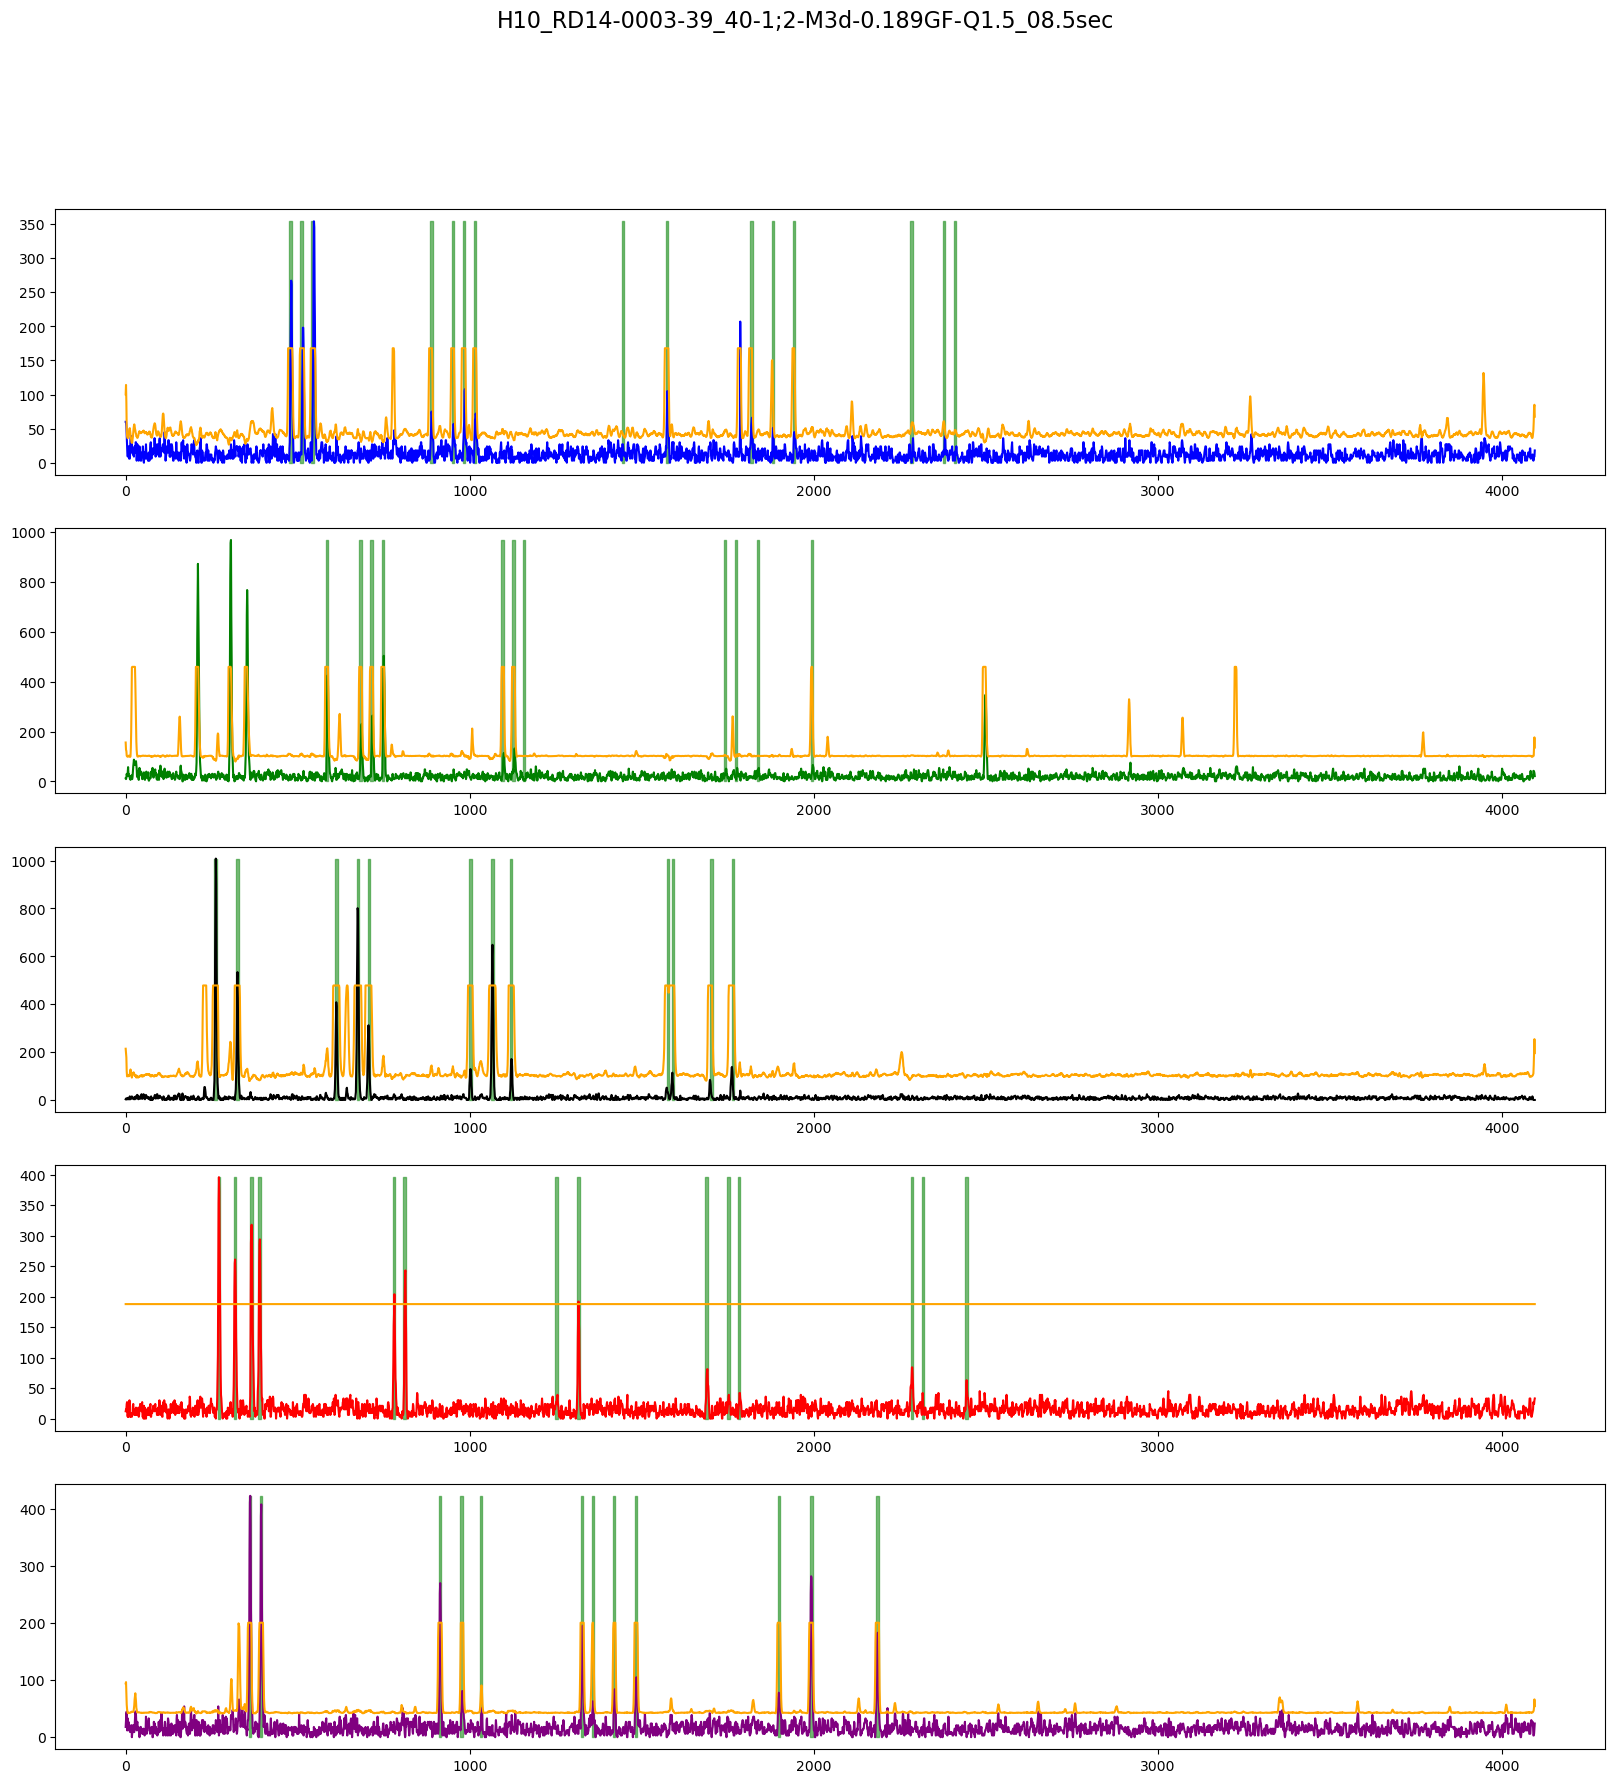

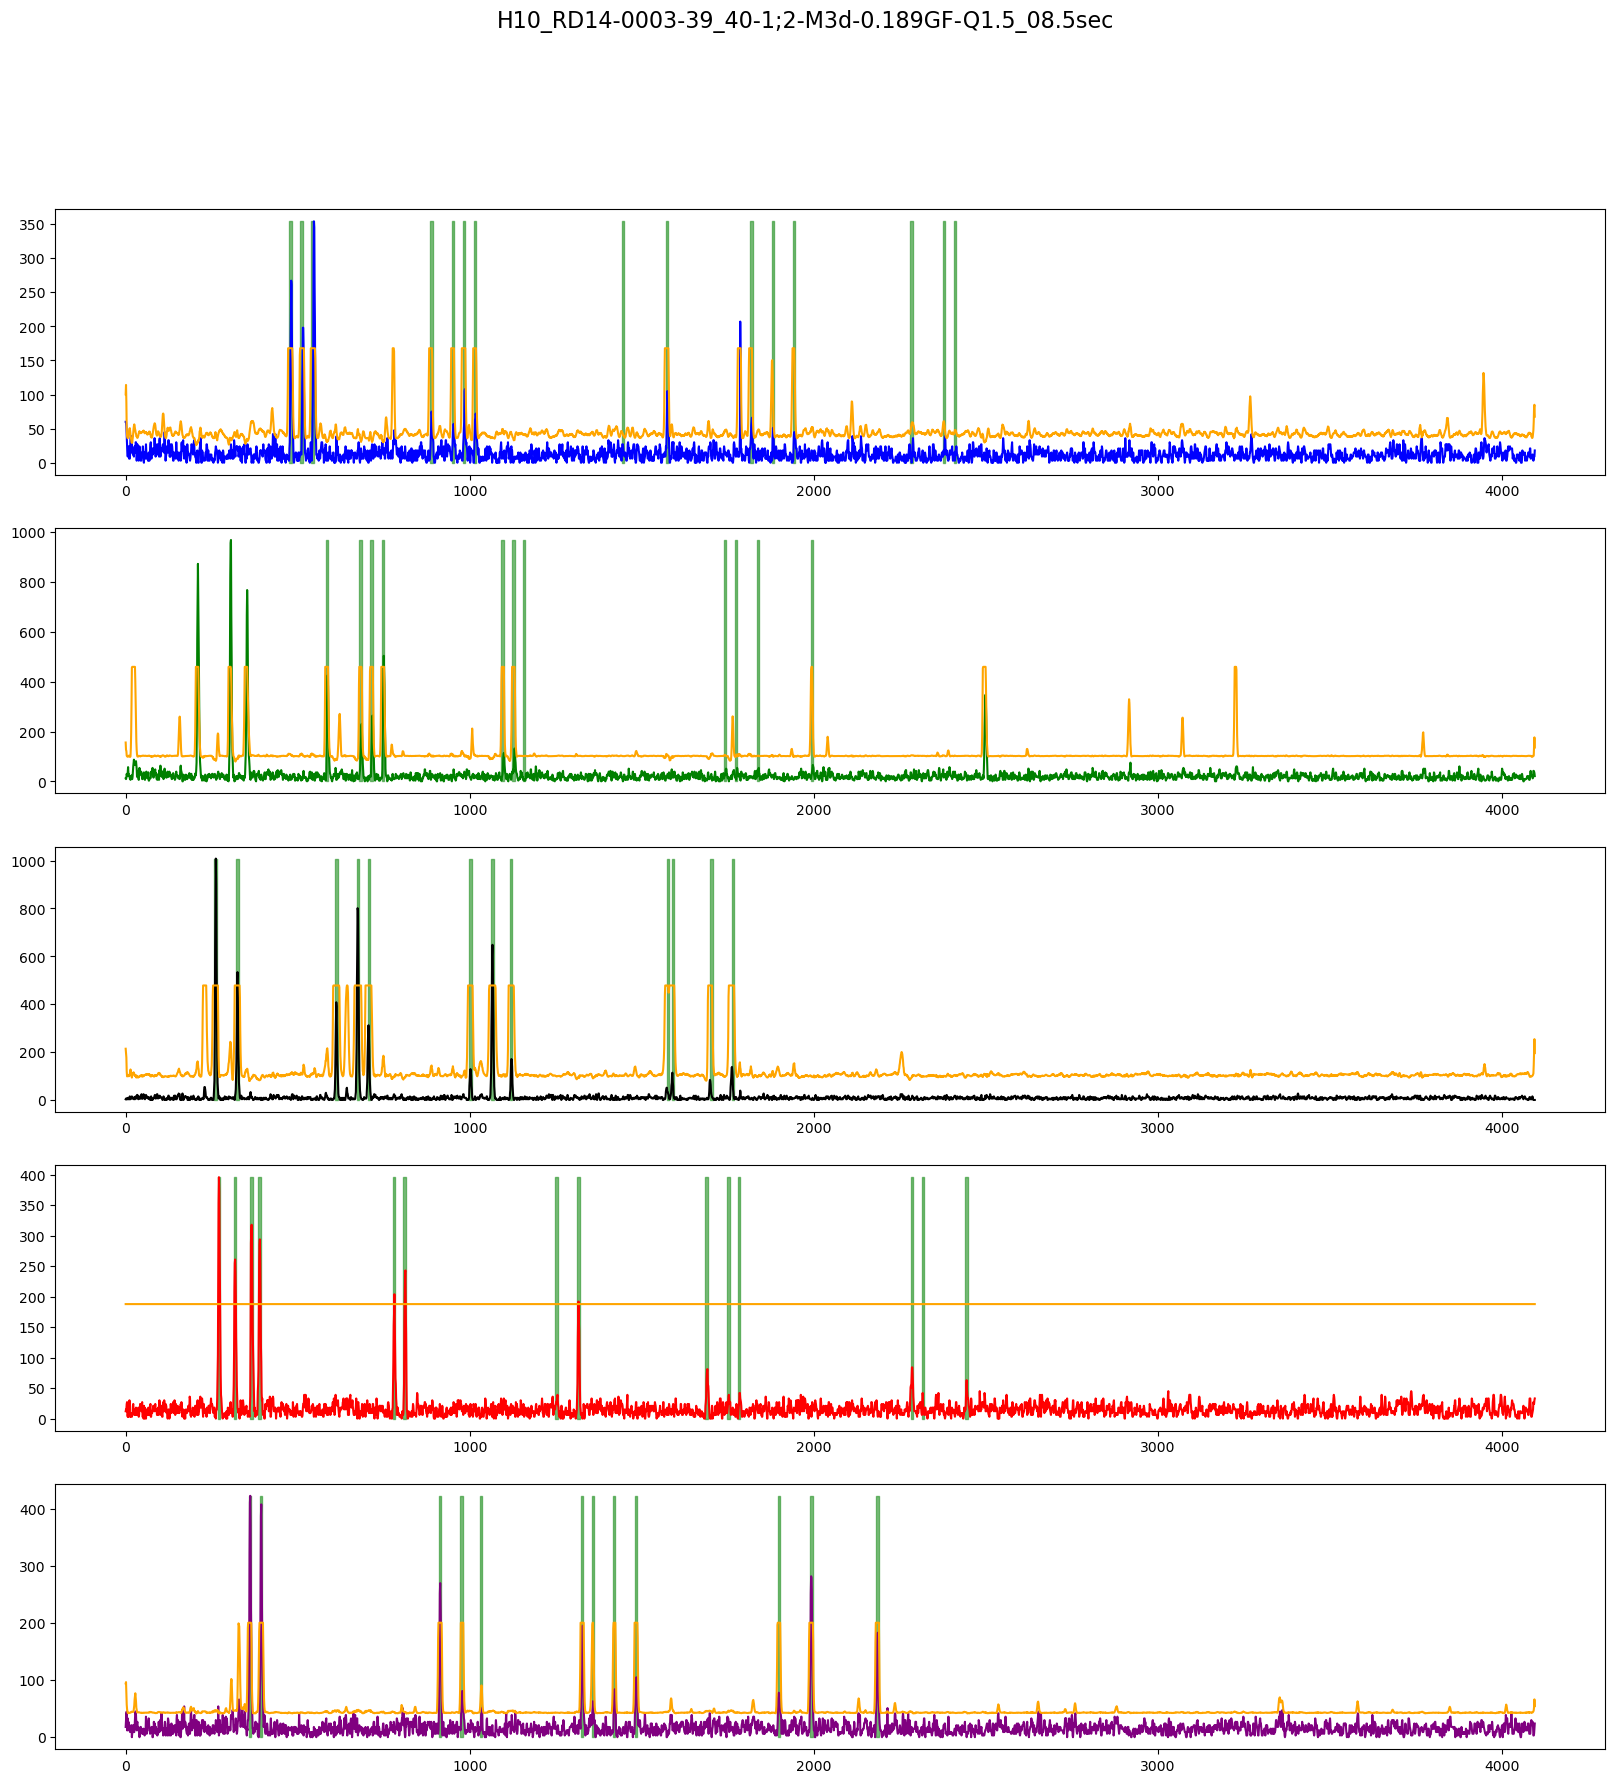

In [ ]:
from DNAnet.evaluation.visualizations import plot_profile


plot_profile(images[:1], predictions[:1], prediction_as_mask=False)

In [ ]:
best_unet_model = load_model("config/models/unet.yaml")
best_unet_model.load("resources/model/current_best_unet/")

In [ ]:
best_predictions = best_unet_model.predict_batch(images[:1])

2025-06-27 17:26:35 INFO     Calling alleles from predicted segmentation...


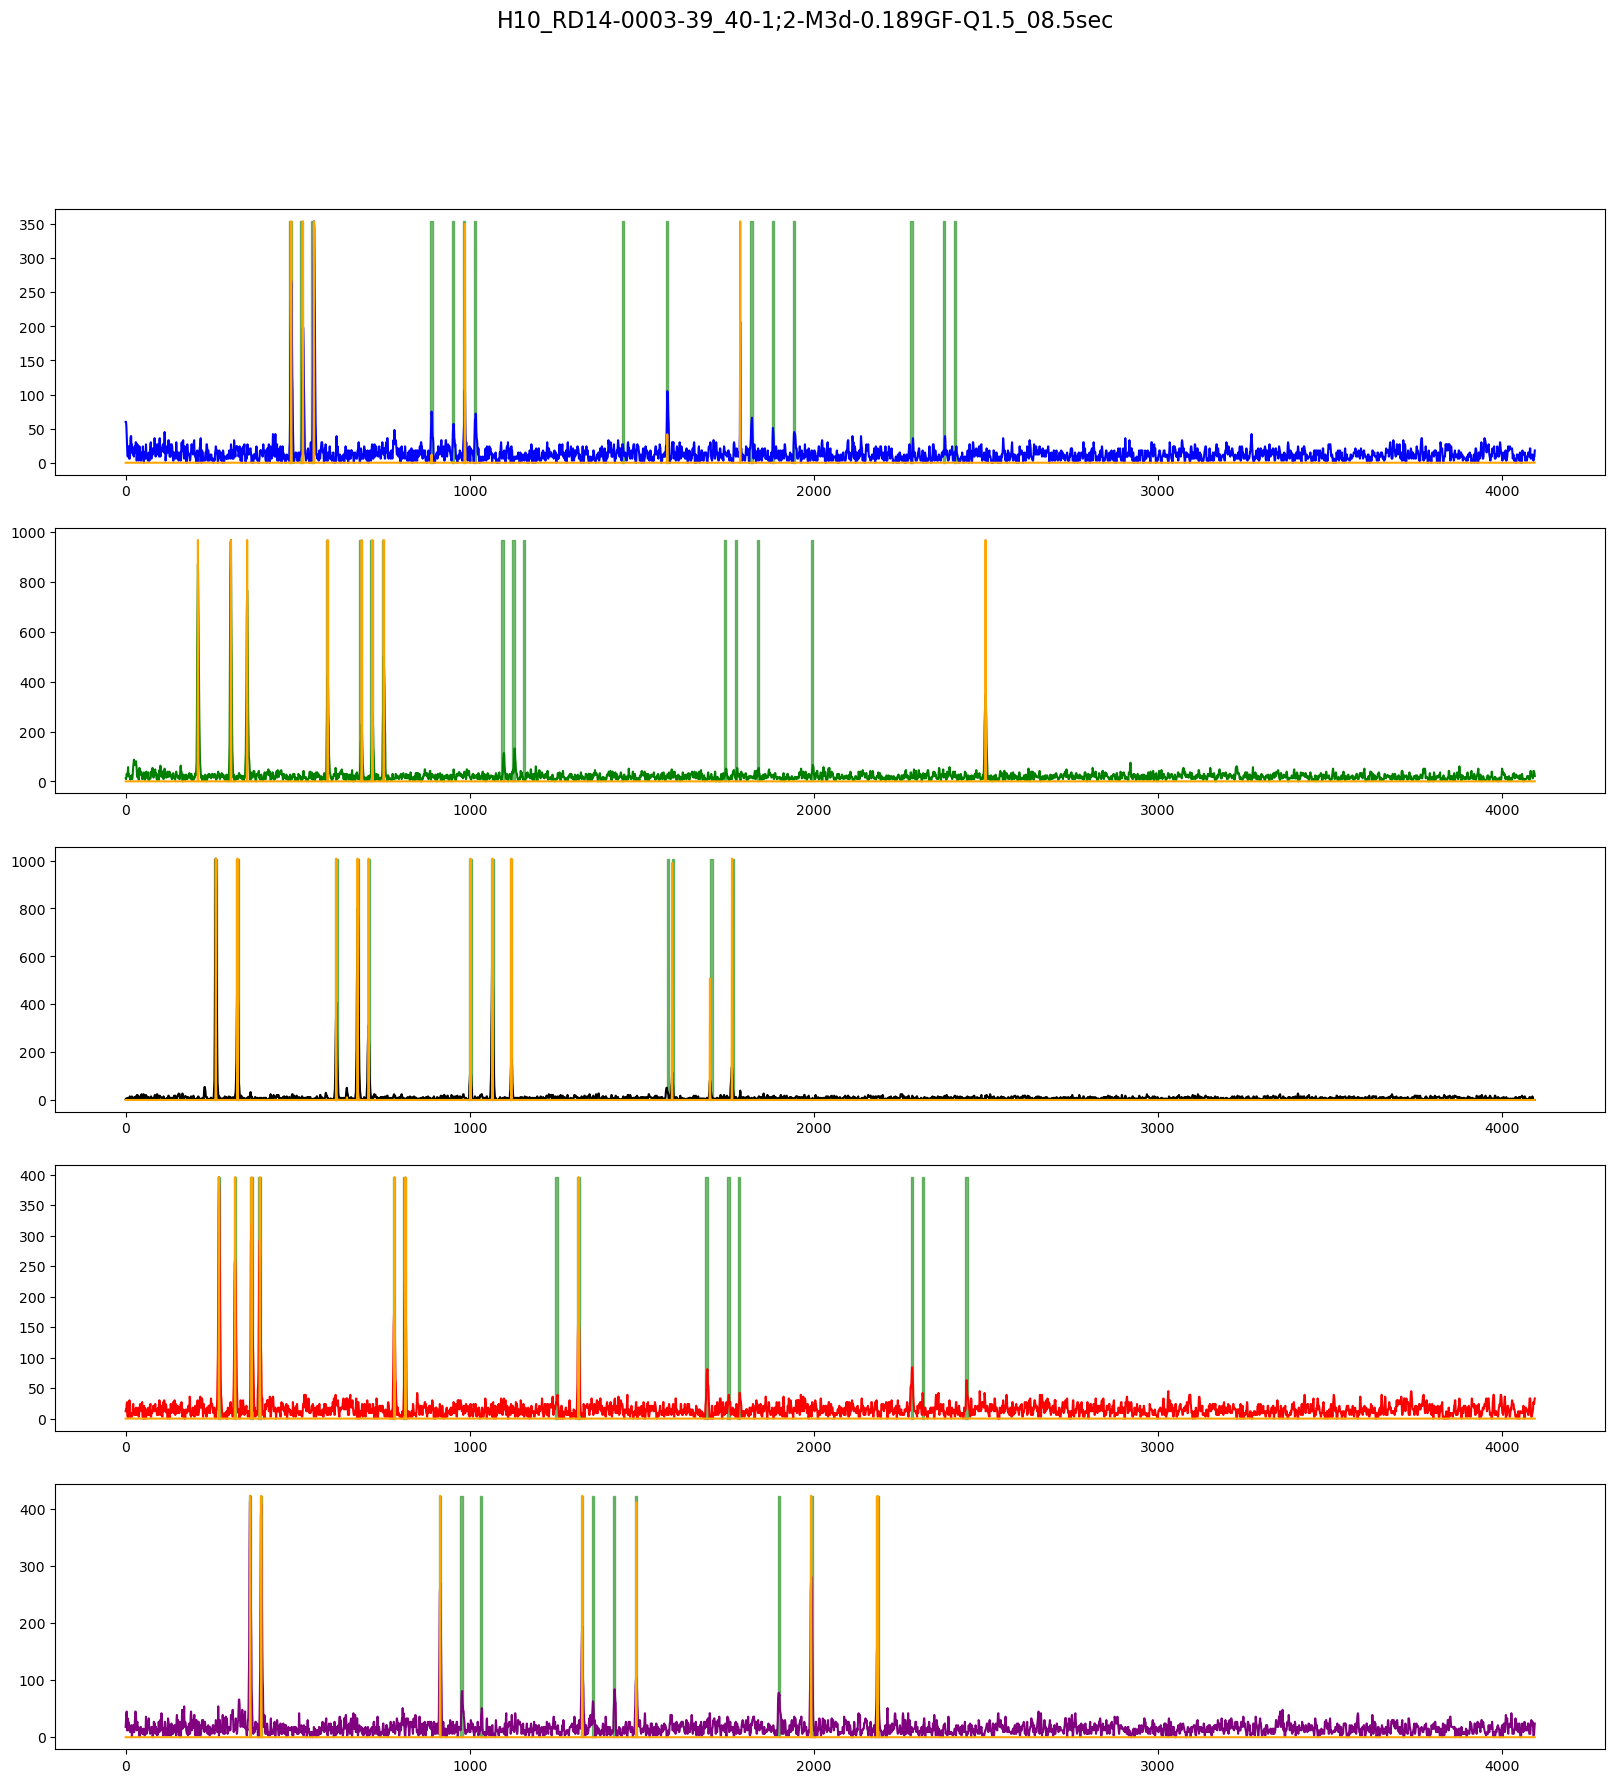

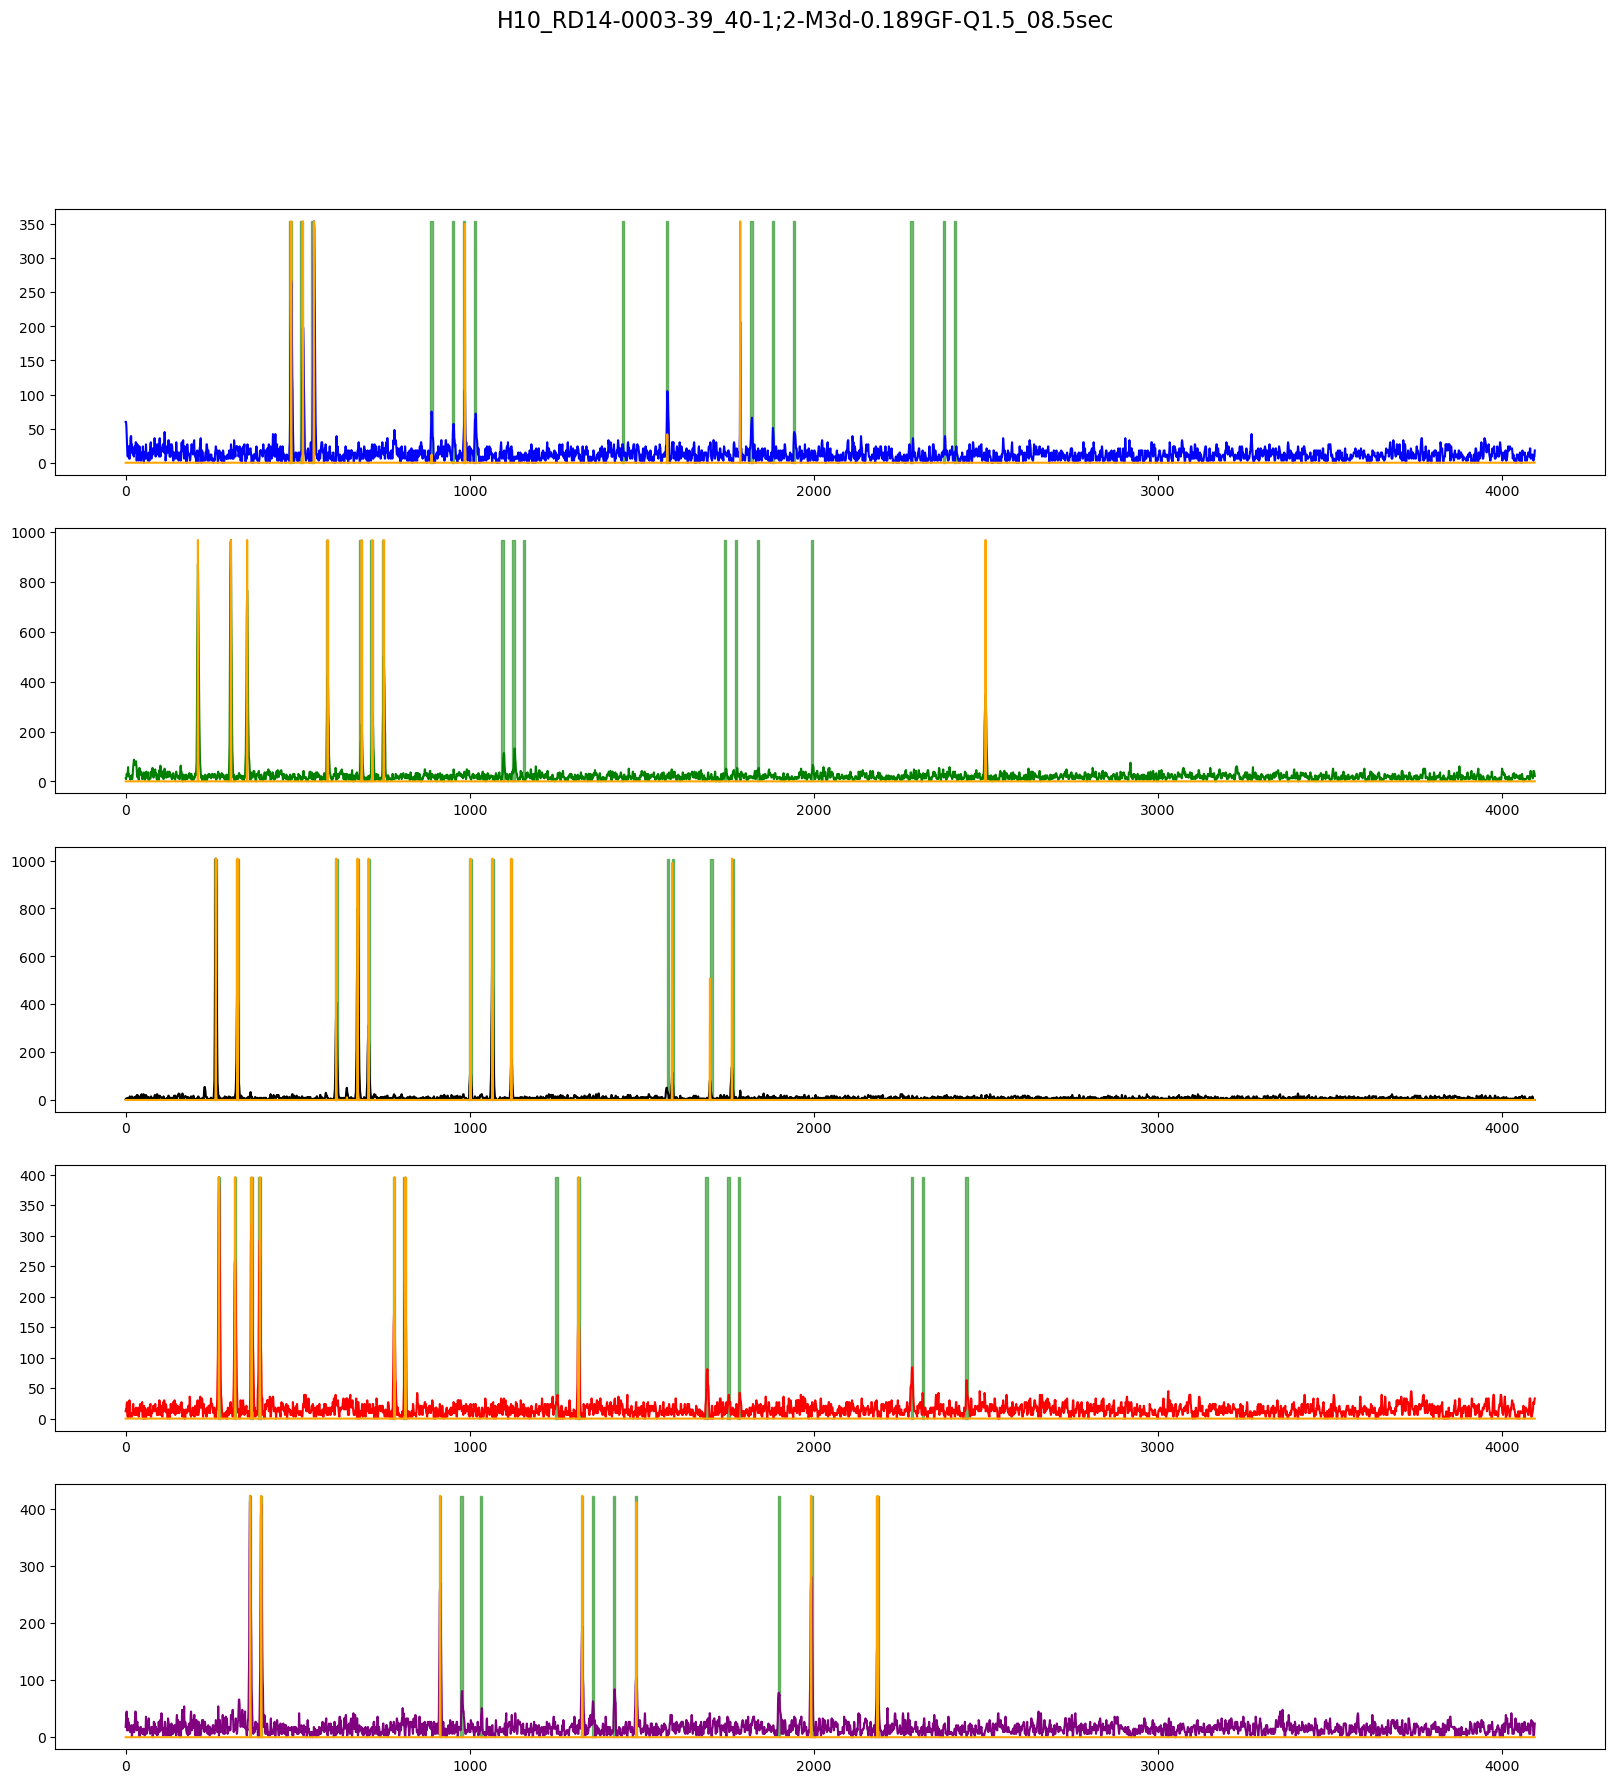

In [ ]:
plot_profile(images[:1], best_predictions[:1], prediction_as_mask=False)